#### Data Frames
****

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.formula.api import ols
import seaborn as sns
import math
import random
import itertools
import scipy.stats as stats
import statsmodels as sm
from statsmodels.stats.anova import anova_lm

## Problem 1: Extending the Lady Tasting Tea
*******

In [3]:
# Number of cups of tea in total.
no_cups = 12

# Number of cups of tea with tea in first.
no_cups_tea_first = 8

# Number of cups of tea with milk in first.
no_cups_milk_first = 4



In [4]:
ways = math.comb(no_cups, no_cups_milk_first)

# Show.
ways

495

In [5]:
# Number of cups of tea in total.
n = 12
# Number of cups of tea with milk in first.
k = 8
math.factorial(n)
math.factorial(k)

40320

In [6]:
math.factorial(n - k)

24

In [7]:
# No of ways of selecting k objects from n without replacement and without order.
math.factorial(n) // (math.factorial(k) * math.factorial(n - k))

495

In [8]:
# The cup labels.
labels = list(range(no_cups))

# Show.
labels

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [9]:
# Show the different ways of selecting no_cups_milk_first out of no_cups cups of tea.
combs = list(itertools.combinations(labels, no_cups_milk_first))

# Show.
combs

[(0, 1, 2, 3),
 (0, 1, 2, 4),
 (0, 1, 2, 5),
 (0, 1, 2, 6),
 (0, 1, 2, 7),
 (0, 1, 2, 8),
 (0, 1, 2, 9),
 (0, 1, 2, 10),
 (0, 1, 2, 11),
 (0, 1, 3, 4),
 (0, 1, 3, 5),
 (0, 1, 3, 6),
 (0, 1, 3, 7),
 (0, 1, 3, 8),
 (0, 1, 3, 9),
 (0, 1, 3, 10),
 (0, 1, 3, 11),
 (0, 1, 4, 5),
 (0, 1, 4, 6),
 (0, 1, 4, 7),
 (0, 1, 4, 8),
 (0, 1, 4, 9),
 (0, 1, 4, 10),
 (0, 1, 4, 11),
 (0, 1, 5, 6),
 (0, 1, 5, 7),
 (0, 1, 5, 8),
 (0, 1, 5, 9),
 (0, 1, 5, 10),
 (0, 1, 5, 11),
 (0, 1, 6, 7),
 (0, 1, 6, 8),
 (0, 1, 6, 9),
 (0, 1, 6, 10),
 (0, 1, 6, 11),
 (0, 1, 7, 8),
 (0, 1, 7, 9),
 (0, 1, 7, 10),
 (0, 1, 7, 11),
 (0, 1, 8, 9),
 (0, 1, 8, 10),
 (0, 1, 8, 11),
 (0, 1, 9, 10),
 (0, 1, 9, 11),
 (0, 1, 10, 11),
 (0, 2, 3, 4),
 (0, 2, 3, 5),
 (0, 2, 3, 6),
 (0, 2, 3, 7),
 (0, 2, 3, 8),
 (0, 2, 3, 9),
 (0, 2, 3, 10),
 (0, 2, 3, 11),
 (0, 2, 4, 5),
 (0, 2, 4, 6),
 (0, 2, 4, 7),
 (0, 2, 4, 8),
 (0, 2, 4, 9),
 (0, 2, 4, 10),
 (0, 2, 4, 11),
 (0, 2, 5, 6),
 (0, 2, 5, 7),
 (0, 2, 5, 8),
 (0, 2, 5, 9),
 (0, 2, 5, 10),
 (

In [10]:
# Number of combinations.
len(combs)

495

In [ ]:
# Select four cups at random to put milk in first.
labels_milk = random.sample(labels, 4)

# Sort, inplace.
labels_milk.sort()

# Show.
labels_milk

[1, 3, 6, 9]

In [ ]:
# Turn labels_milk into a set.
set(labels_milk)

{1, 3, 6, 9}

In [13]:
no_overlaps = []

# Loop through the combinations.
for comb in combs:
  # Turn comb into a set.
  s1 = set(comb)
  # Turn labels_milk into a set.
  s2 = set(labels_milk)
  # Figure out where they overlap.
  overlap = s1.intersection(s2)
  # Show the combination and the overlap.
  print(comb, len(overlap), overlap)
  # Append overlap to no_overlaps.
  no_overlaps.append(len(overlap))


(0, 1, 2, 3) 2 {1, 3}
(0, 1, 2, 4) 1 {1}
(0, 1, 2, 5) 1 {1}
(0, 1, 2, 6) 2 {1, 6}
(0, 1, 2, 7) 1 {1}
(0, 1, 2, 8) 1 {1}
(0, 1, 2, 9) 2 {1, 9}
(0, 1, 2, 10) 1 {1}
(0, 1, 2, 11) 1 {1}
(0, 1, 3, 4) 2 {1, 3}
(0, 1, 3, 5) 2 {1, 3}
(0, 1, 3, 6) 3 {1, 3, 6}
(0, 1, 3, 7) 2 {1, 3}
(0, 1, 3, 8) 2 {1, 3}
(0, 1, 3, 9) 3 {1, 3, 9}
(0, 1, 3, 10) 2 {1, 3}
(0, 1, 3, 11) 2 {1, 3}
(0, 1, 4, 5) 1 {1}
(0, 1, 4, 6) 2 {1, 6}
(0, 1, 4, 7) 1 {1}
(0, 1, 4, 8) 1 {1}
(0, 1, 4, 9) 2 {1, 9}
(0, 1, 4, 10) 1 {1}
(0, 1, 4, 11) 1 {1}
(0, 1, 5, 6) 2 {1, 6}
(0, 1, 5, 7) 1 {1}
(0, 1, 5, 8) 1 {1}
(0, 1, 5, 9) 2 {1, 9}
(0, 1, 5, 10) 1 {1}
(0, 1, 5, 11) 1 {1}
(0, 1, 6, 7) 2 {1, 6}
(0, 1, 6, 8) 2 {1, 6}
(0, 1, 6, 9) 3 {1, 6, 9}
(0, 1, 6, 10) 2 {1, 6}
(0, 1, 6, 11) 2 {1, 6}
(0, 1, 7, 8) 1 {1}
(0, 1, 7, 9) 2 {1, 9}
(0, 1, 7, 10) 1 {1}
(0, 1, 7, 11) 1 {1}
(0, 1, 8, 9) 2 {1, 9}
(0, 1, 8, 10) 1 {1}
(0, 1, 8, 11) 1 {1}
(0, 1, 9, 10) 2 {1, 9}
(0, 1, 9, 11) 2 {1, 9}
(0, 1, 10, 11) 1 {1}
(0, 2, 3, 4) 1 {3}
(0, 2, 3, 5) 1 {3}
(0, 2, 3

In [14]:
# Show the overlaps.
print(no_overlaps)

[2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 3, 2, 2, 3, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 3, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 2, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 3, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 1, 0, 0, 1, 0, 0, 1, 1, 2, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 2, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 2, 2, 3, 2, 2, 3, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 3, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 2, 3, 2, 2, 3, 2, 2, 3, 2, 2, 3, 2, 2, 3, 3, 4, 3, 3, 2, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 1, 1, 2, 1, 1, 2, 2, 3, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 2, 2, 3, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 2, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 1, 1, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 3, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 1, 0, 0, 1, 0, 0, 1, 1, 2, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 

In [15]:
# Count the number of times each overlap occurs.
counts = np.unique(no_overlaps, return_counts=True)

# Show.
counts

(array([0, 1, 2, 3, 4]), array([ 70, 224, 168,  32,   1], dtype=int64))

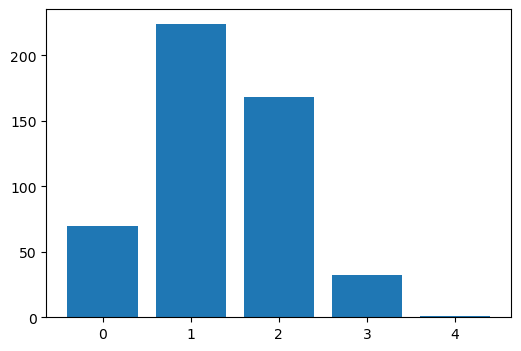

In [16]:
# Create a figure.
fig, ax = plt.subplots(figsize=(6, 4))

# Bar chart.
ax.bar(counts[0], counts[1]);

****

##### References:
- [Code Base](https://github.com/ianmcloughlin/applied-statistics/blob/main/materials/lady-tasting-tea.ipynb)
- [Random](https://docs.python.org/3/library/random.html#random.sample)
- [Sets](https://docs.python.org/3/tutorial/datastructures.html#sets)

## Problem 2: Normal Distribution
*******

In [17]:
# Generating samples
n_samples = 100_000
sample_size = 10

# Generate a 100,000 × 10 array of standard normal samples
data = np.random.normal(loc=0, scale=1, size=(n_samples, sample_size))

In [18]:
# Compute standard deviations

# Population standard deviation (ddof=0)
pop_sd = np.std(data, axis=1, ddof=0)

# Sample standard deviation (ddof=1)
sample_sd = np.std(data, axis=1, ddof=1)

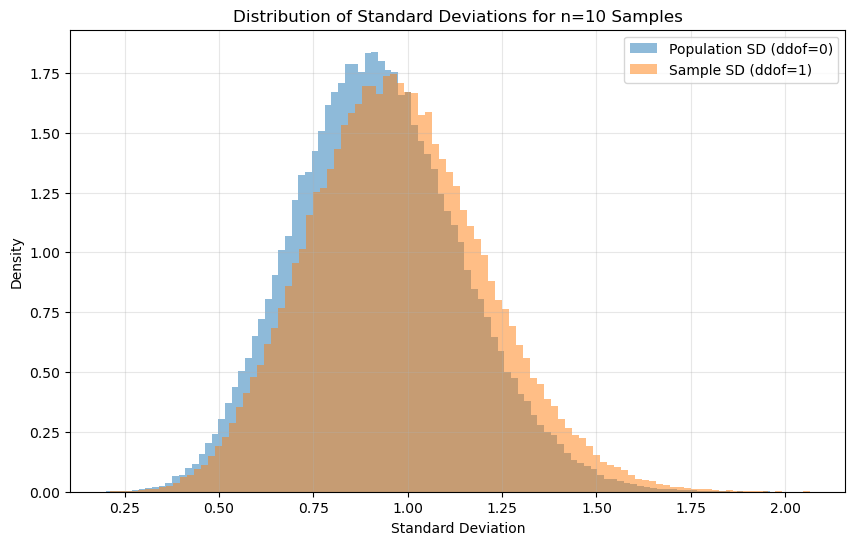

In [19]:
# Plot histograms

plt.figure(figsize=(10, 6))

plt.hist(pop_sd, bins=100, alpha=0.5, label='Population SD (ddof=0)', density=True)
plt.hist(sample_sd, bins=100, alpha=0.5, label='Sample SD (ddof=1)', density=True)

plt.title("Distribution of Standard Deviations for n=10 Samples")
plt.xlabel("Standard Deviation")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

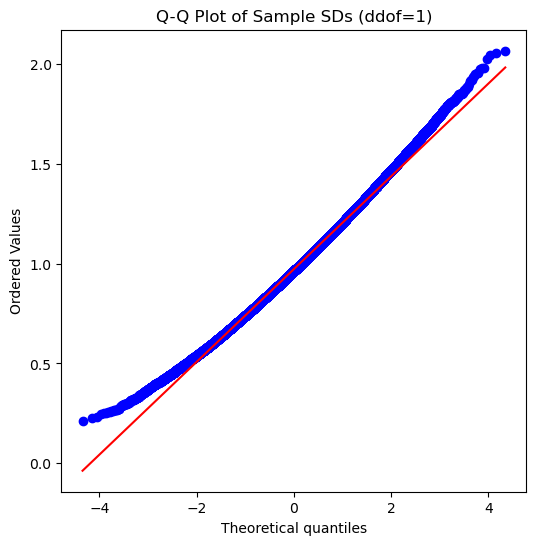

In [20]:
# Create an empty plot
fig, ax = plt.subplots(figsize=(6, 6))

# Q-Q plot of the sample standard deviations
stats.probplot(sample_sd, dist="norm", plot=ax)

ax.set_title("Q-Q Plot of Sample SDs (ddof=1)")
plt.show()

****

#### Description of the Simulation

We generate 100,000 independent samples of size n=10 from the standard normal distribution. For each sample, two estimates of the standard deviation are computed:

- The population standard deviation using ddof = 0, and
- The sample standard deviation using ddof = 1, which applies Bessel’s correction.

Histograms of both sets of standard deviations are plotted on the same axes to compare their empirical distributions.

****

#### Observed Differences

- The distribution of the sample standard deviation (ddof = 1) is shifted slightly to the right compared to the population standard deviation.

- This occurs because Bessel’s correction divides by n−1 instead of n, inflating the variance estimate to correct for the downward bias resent in the population estimator.

- The sample SD distribution is therefore less biased but exhibits slightly greater variability.

- Both distributions are right-skewed and are clearly non-normal, as confirmed by the Q–Q plot.

****

#### Effect of Increasing Sample Size

If the sample size were increased:
- The difference between the two distributions would decrease.
- Both estimators would concentrate more tightly around the true population standard deviation (σ=1).
- The bias of the population SD estimator would become negligible.
- The sampling variability of both estimators would decrease, resulting in narrower histograms.
- In the limit as n→∞, the population and sample standard deviation estimators converge and become nearly indistinguishable.

****

#### Key Statistical Takeaway

Bessel’s correction (ddof = 1) corrects bias in variance estimation for small samples. The effect is noticeable for small n, but diminishes as sample size increases.

****

#### Increase Sample size.

To further explore the behavior of the standard deviation estimators, the simulation was repeated for increasing sample sizes. As the sample size increases, both the population and sample standard deviation estimators converge to the true population value (σ = 1). The difference between the two estimators becomes negligible for larger samples, illustrating that the bias of the population standard deviation is mainly a small-sample issue.

In [21]:
# Reproducibility
np.random.seed(42)

# Simulation settings
n_samples = 100_000
sample_sizes = [5, 10, 30, 50, 100]

mean_pop_sd = []
mean_sample_sd = []

In [22]:
for n in sample_sizes:
    # Generate samples
    data = np.random.normal(0, 1, size=(n_samples, n))
    
    # Compute SDs
    pop_sd = np.std(data, axis=1, ddof=0)
    sample_sd = np.std(data, axis=1, ddof=1)
    
    # Store average SDs
    mean_pop_sd.append(np.mean(pop_sd))
    mean_sample_sd.append(np.mean(sample_sd))


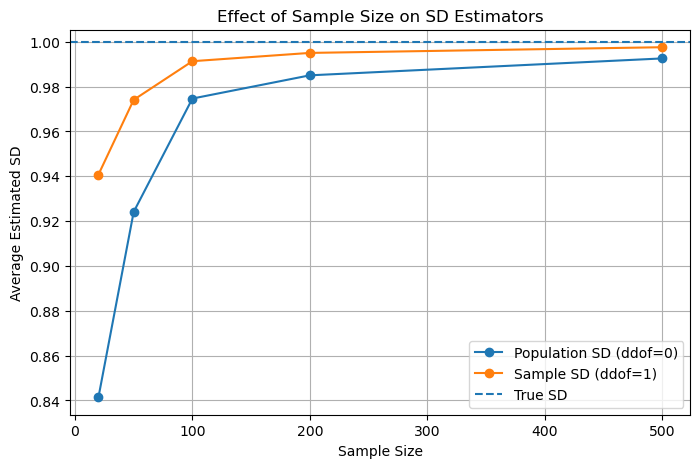

In [40]:

# Plot average SD estimates vs sample size
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, mean_pop_sd, marker='o', label="Population SD (ddof=0)")
plt.plot(sample_sizes, mean_sample_sd, marker='o', label="Sample SD (ddof=1)")
plt.axhline(1, linestyle='--', label="True SD")
plt.xlabel("Sample Size")
plt.ylabel("Average Estimated SD")
plt.title("Effect of Sample Size on SD Estimators")
plt.legend()
plt.grid(True)
plt.show()

******

#### References:
- [Base Code](https://github.com/ianmcloughlin/applied-statistics/blob/main/materials/normal-distribution.ipynb)
- [Numpy.std](https://numpy.org/doc/stable/reference/generated/numpy.std.html)
- [Numpy Random Normal](https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html)
- [ddof](https://stackoverflow.com/questions/27600207/why-does-numpy-std-give-a-different-result-to-matlab-std)

****

## Problem 3: t-Tests
****

In [23]:

# Reproducibility
np.random.seed(42)
n = 100                    # sample size per group
n_simulations = 1000       # repetitions per mean difference
alpha = 0.05               # significance level
# Mean differences to test
delta_values = np.arange(0, 1.1, 0.1)

In [24]:
#Estimate the Type II error rate for an independent samples t-test when the true difference in means is delta.
def type_ii_error_rate(delta, n=100, n_simulations=1000, alpha=0.05):
    failures = 0  
    for _ in range(n_simulations):
        # Sample from N(0, 1)
        x = np.random.normal(0, 1, n)
        
        # Sample from N(delta, 1)
        y = np.random.normal(delta, 1, n)
        
        # Perform independent samples t-test
        _, p_value = ttest_ind(x, y, equal_var=True)
        
        # Fail to reject the null hypothesis
        if p_value >= alpha:
            failures += 1
    
    return failures / n_simulations

In [25]:
type_ii_errors = np.array([
    type_ii_error_rate(delta) for delta in delta_values
])

# Corresponding power values
power = 1 - type_ii_errors

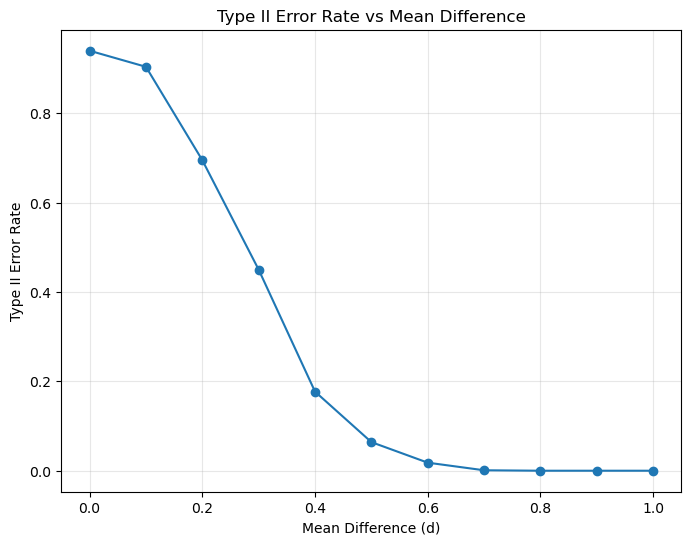

In [ ]:
#Plot Rate vs Mean Difference
plt.figure(figsize=(8, 6))

plt.plot(delta_values, type_ii_errors, marker='o')
plt.xlabel("Mean Difference (d)")
plt.ylabel("Type II Error Rate")
plt.title("Type II Error Rate vs Mean Difference")
plt.grid(alpha=0.3)

plt.show()

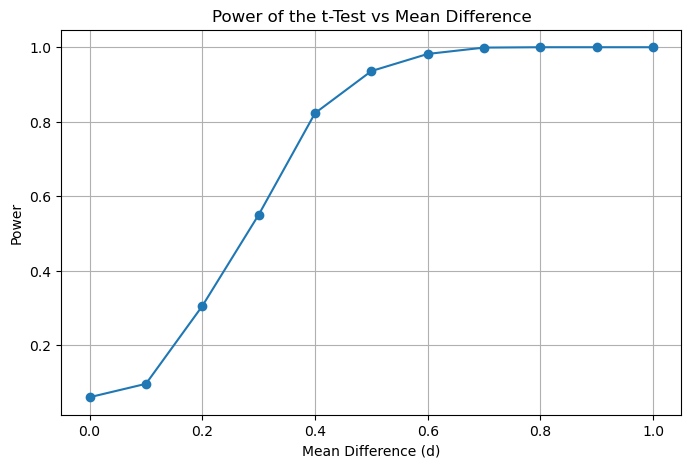

In [ ]:
#Plot t-Test vs Mean difference

plt.figure(figsize=(8, 5))
plt.plot(delta_values, power, marker='o')
plt.xlabel("Mean Difference (d)")
plt.ylabel("Power")
plt.title("Power of the t-Test vs Mean Difference")
plt.grid(True)
plt.show()

****

#### Interpretation:

- When the mean difference is small, the two distributions overlap heavily.
- The t-test struggles to detect a difference.
- The Type II error rate is high and power is low.
- As the mean difference increases, the distributions separate.
- The t-test detects differences more reliably.
- The Type II error rate decreases.
- Power increases toward 1.

This behavior is consistent with statistical theory: larger effect sizes lead to higher power.

- When δ = 0, the null hypothesis is true, so “Type II error” is not meaningful.
- For δ > 0, the null hypothesis is false, and failing to reject it constitutes a Type II error.

Increasing:

- sample size
- significance level
- or effect size
would further increase power.

****

#### Effect of Sample Size on Type II Error

##### Goal

Instead of fixing n = 100, we:
- Vary the sample size
- Examine how Type II error behaves for a fixed mean difference

In [28]:
# Reproducibility
np.random.seed(42)

# Simulation parameters
alpha = 0.05                # significance level             
n_simulations = 1000        # number of simulations
delta = 0.3                 # fixed mean difference
sample_sizes = [20, 50, 100, 200, 500]


In [29]:
def type_ii_error_rate(delta, n, n_simulations=1000, alpha=0.05):
    #Estimate Type II error rate for a given sample size.
    failures = 0
    
    for _ in range(n_simulations):
        x = np.random.normal(0, 1, n)
        y = np.random.normal(delta, 1, n)
        
        # Perform Student's t-test
        _, p = ttest_ind(x, y, equal_var=True)
        
        # Count failure to reject H0
        if p >= alpha:
            failures += 1
            
    return failures / n_simulations


In [30]:
# Compute Type II error rate for each sample size
type_ii_errors_n = np.array([
    type_ii_error_rate(delta, n) for n in sample_sizes
])

# Convert Type II error rates to power
power_n = 1 - type_ii_errors_n

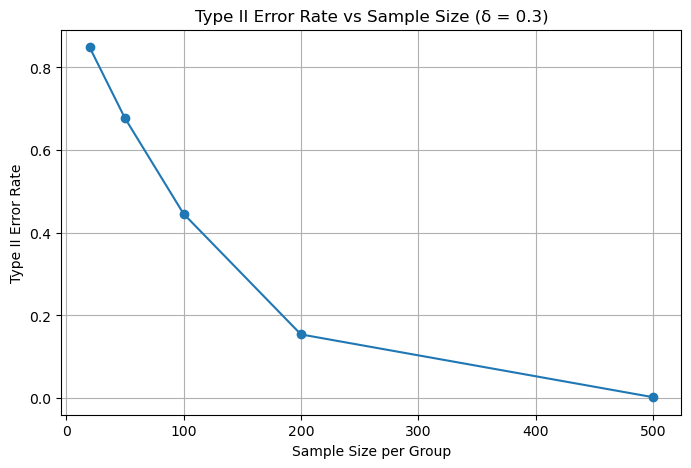

In [31]:

# Plot Type II error rate vs sample size

plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, type_ii_errors_n, marker='o')
plt.xlabel("Sample Size per Group")
plt.ylabel("Type II Error Rate")
plt.title(f"Type II Error Rate vs Sample Size (δ = {delta})")
plt.grid(True)
plt.show()


***

#### Interpretation

- For small sample sizes, sampling variability is large.
- The t-test often fails to detect the true difference.
- Type II error rate is high.

##### As the sample size increases:
- The sampling distribution becomes tighter.
- The test statistic increases in magnitude.
- Type II error decreases rapidly.

This demonstrates that power increases with sample size, even when the effect size remains fixed.

****

#### Student’s vs Welch’s t-test

##### Student’s t-test:
- Assumes equal variances in the two populations
- Uses a pooled variance estimate
- Slightly more powerful when the assumption is true

##### Welch’s t-test:
- Does not assume equal variances
- Uses separate variance estimates and adjusted degrees of freedom
- More robust when variances differ
- Default in many statistical packages

In [32]:
# Simulation parameters
np.random.seed(42)

n = 100
n_simulations = 1000
alpha = 0.05
delta = 0.3

# Population standard deviations
sigma_1 = 1.0
sigma_2 = 2.0    # unequal variance


In [33]:
def type_ii_error_rate_ttest(delta, n, sigma_1, sigma_2,
                             equal_var, n_simulations=1000, alpha=0.05):
#Estimate Type II error rate via Monte Carlo simulation.
    failures = 0
    
    for _ in range(n_simulations):
        # Generate samples
        x = np.random.normal(0, sigma_1, n)
        y = np.random.normal(delta, sigma_2, n)
        
        # Perform t-test (Student or Welch)
        _, p = ttest_ind(x, y, equal_var=equal_var)
        
        # Count failure to reject H0
        if p >= alpha:
            failures += 1
            
    return failures / n_simulations


In [34]:
# Type II error rates
type_ii_student = type_ii_error_rate_ttest(
    delta, n, sigma_1, sigma_2, equal_var=True
)

type_ii_welch = type_ii_error_rate_ttest(
    delta, n, sigma_1, sigma_2, equal_var=False
)


# Convert to power
power_student = 1 - type_ii_student
power_welch = 1 - type_ii_welch


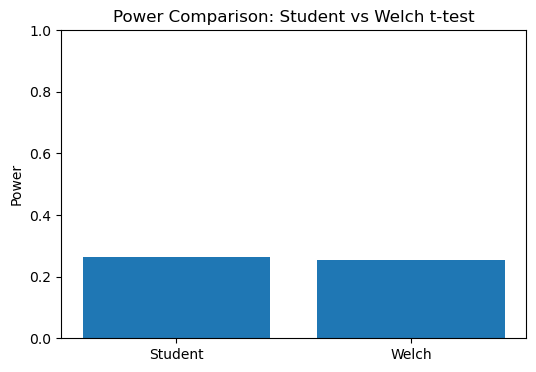

In [35]:

# Plot power comparison

labels = ["Student", "Welch"]
power_values = [power_student, power_welch]

plt.figure(figsize=(6, 4))
plt.bar(labels, power_values)
plt.ylabel("Power")
plt.title("Power Comparison: Student vs Welch t-test")
plt.ylim(0, 1)
plt.show()


****

#### Interpretation 

- When the equal variance assumption is violated, Student’s t-test can lose power.
- Welch’s t-test remains robust and often outperforms Student’s test in terms of power.

This supports the common recommendation to prefer Welch’s t-test in practice, especially when variance equality is uncertain.

Important Subtle Point:

If variances are actually equal, Student’s t-test may have slightly higher power — but the difference is usually negligible.


***

### References:

- [T-tests code example](https://github.com/ianmcloughlin/applied-statistics/blob/main/materials/t-tests.ipynb)
- [Student vs Welsh t-test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
- [Power Curve](https://matplotlib.org/stable/tutorials/pyplot.html)

## Problem 4: ANOVA
*****

In [36]:
# Set a random seed for reproducibility
np.random.seed(42)

# 1) Generate three independent samples (n=30 each)
n = 30
sample1 = np.random.normal(loc=0,   scale=1, size=n)
sample2 = np.random.normal(loc=0.5, scale=1, size=n)
sample3 = np.random.normal(loc=1,   scale=1, size=n)


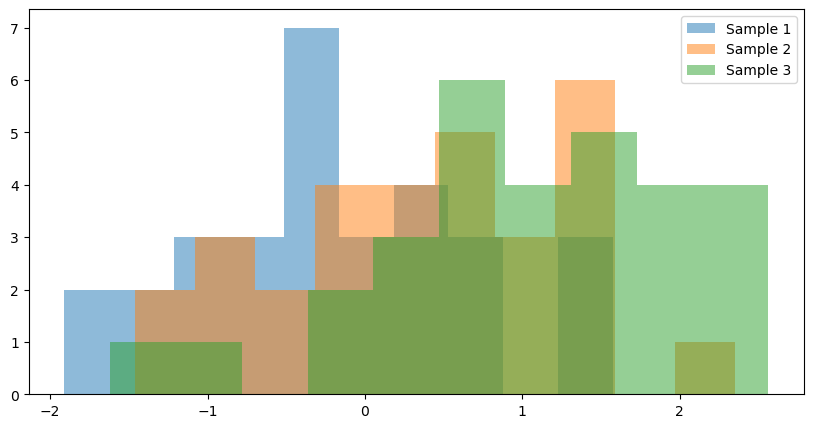

In [37]:
# Create histograms.
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram of the first sample.
ax.hist(sample1, bins=10, alpha=0.5, label='Sample 1')

# Histogram of the second sample.
ax.hist(sample2, bins=10, alpha=0.5, label='Sample 2')

# Histogram of the third sample.
ax.hist(sample3, bins=10, alpha=0.5, label='Sample 3')

# Add a legend.
ax.legend();

In [38]:
# Put in a DataFrame for statsmodels (long/tidy format)
df = pd.DataFrame({
    "value": np.concatenate([sample1, sample2, sample3]),
    "group": (["G1"] * n) + (["G2"] * n) + (["G3"] * n)
})

# Show first few rows
df.head()

,value,group
0,0.496714,G1
1,-0.138264,G1
2,0.647689,G1
3,1.523030,G1
4,-0.234153,G1


In [42]:
# One-way ANOVA
model = ols('value ~ C(group)', data=df).fit()
anova_table = anova_lm(model, typ=2)

print("=== One-way ANOVA ===")
print(anova_table)

=== One-way ANOVA ===
             sum_sq    df          F    PR(>F)
C(group)  21.659643   2.0  12.209526  0.000021
Residual  77.168804  87.0        NaN       NaN


In [ ]:
# 3) Pairwise two-sample t-tests
t12 = stats.ttest_ind(sample1, sample2)
t13 = stats.ttest_ind(sample1, sample3)
t23 = stats.ttest_ind(sample2, sample3)

print("=== Pairwise t-tests ===")
print("Sample1 vs Sample2:", t12)
print("Sample1 vs Sample3:", t13)
print("Sample2 vs Sample3:", t23)

=== Pairwise t-tests ===
Sample1 vs Sample2: TtestResult(statistic=-2.398115152010245, pvalue=0.019717941865758044, df=58.0)
Sample1 vs Sample3: TtestResult(statistic=-4.911326340958337, pvalue=7.737964508099687e-06, df=58.0)
Sample2 vs Sample3: TtestResult(statistic=-2.5525907328394117, pvalue=0.013347246886682384, df=58.0)


****

### Why ANOVA is Preferred Over Several t-tests

Running multiple two-sample t-tests increases the familywise error rate: the more tests you do, the greater the chance of finding false positives just by chance.

ANOVA tests the global null hypothesis that all group means are equal using one overall test at a chosen significance level (e.g., 0.05), keeping the Type I error rate controlled.

If the ANOVA is significant, then post-hoc pairwise comparisons (with adjustments such as Tukey’s HSD) can be done. This approach avoids inflation of Type I error that would come from doing multiple unadjusted t-tests.

### References:
 - [Anova Statistics](https://statistics.laerd.com/spss-tutorials/one-way-anova-using-spss-statistics.php)
 - [Base Code](https://github.com/ianmcloughlin/applied-statistics/blob/main/materials/anova.ipynb)
 - [Anova Stasmodel](https://www.geeksforgeeks.org/data-analysis/how-to-obtain-anova-table-with-statsmodels/?utm_source=chatgpt.com)
 - [Example A](https://thequackdaddy.github.io/statsmodels.github.io/stable/generated/statsmodels.stats.anova.anova_lm.html?utm_source=chatgpt.com)
 - [Example B](https://www.statsmodels.org/dev/anova.html?utm_source=chatgpt.com) 